In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from patsy.builtins import Q
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm

In [5]:
data = pd.read_csv('StudentsPerformance.csv')

In [6]:
# Simulate Teaching Method
np.random.seed(42)
methods = ['Lecture', 'Online', 'Blended']
data['teaching_method'] = np.random.choice(methods, size=len(data))
data['teaching_method'] = data['teaching_method'].astype('category')
data['gender'] = data['gender'].astype('category')
print('Counts by teaching method:')
print(data['teaching_method'].value_counts())
print('\nCounts by gender:')
print(data['gender'].value_counts())


Counts by teaching method:
teaching_method
Lecture    355
Online     326
Blended    319
Name: count, dtype: int64

Counts by gender:
gender
female    518
male      482
Name: count, dtype: int64


## One-Way ANOVA: Teaching Method → Math Score

Research question: Does teaching method (Lecture, Online, Blended) affect students' math scores?

/tmp/ipykernel_2747/3996020545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='teaching_method', y='math score', data=data, palette='Set2')


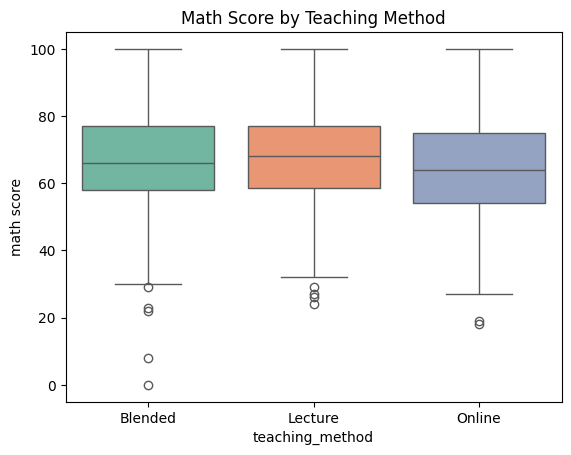


Group means:
teaching_method
Blended    66.257053
Lecture    67.416901
Online     64.478528
Name: math score, dtype: float64


/tmp/ipykernel_2747/3996020545.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('teaching_method')['math score'].mean())


In [7]:
# EDA
sns.boxplot(x='teaching_method', y='math score', data=data, palette='Set2')
plt.title('Math Score by Teaching Method')
plt.show()
print('\nGroup means:')
print(data.groupby('teaching_method')['math score'].mean())


In [ ]:
# Assumption checks
print('Shapiro-Wilk normality test by group:')
for m in data['teaching_method'].cat.categories:
    vals = data.loc[data['teaching_method']==m, 'math score']
    stat,p = stats.shapiro(vals)
    print(f'{m}: W={stat:.3f}, p={p:.4f}')
stat,p = stats.levene(
    data.loc[data['teaching_method']=='Lecture','math score'],
    data.loc[data['teaching_method']=='Online','math score'],
    data.loc[data['teaching_method']=='Blended','math score']
)
print('\nLevene test for equal variances: W={:.3f}, p={:.4f}'.format(stat,p))


In [ ]:
# One-Way ANOVA
model1 = ols('`math score` ~ C(teaching_method)', data=data).fit()
anova1 = sm.stats.anova_lm(model1, typ=2)
print('One-Way ANOVA results:')
print(anova1)


### Instructor Interpretation (One-Way ANOVA)

Read the ANOVA table above. Use the following template to report results (replace placeholders with actual numbers from the table):

- "The one-way ANOVA showed that teaching method had a significant effect on math scores, F(2, N-3) = **F_VALUE**, p = **P_VALUE**."
- If p < 0.05: "Post-hoc Tukey HSD revealed that **[METHOD_A]** differed significantly from **[METHOD_B]** (p = ...)."
- If p >= 0.05: "No statistically significant difference in mean math scores was found among teaching methods."


In [ ]:
# Tukey HSD post-hoc if significant
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey1 = pairwise_tukeyhsd(endog=data['math score'], groups=data['teaching_method'], alpha=0.05)
print(tukey1)
tukey1.plot_simultaneous()
plt.title('Tukey HSD: Teaching Method comparisons')
plt.show()


## Two-Way ANOVA: Teaching Method × Gender → Math Score

Research question: Do teaching method and gender both influence math score, and is there an interaction between them?

In [ ]:
# EDA for two-way
sns.boxplot(x='teaching_method', y='math score', hue='gender', data=data)
plt.title('Math Score by Teaching Method and Gender')
plt.show()
print('\nGroup means (method x gender):')
print(data.groupby(['teaching_method','gender'])['math score'].mean().unstack())


In [ ]:
# Assumptions for two-way: Shapiro per cell and Levene across cells
cells = []
print('Shapiro p-values by cell:')
for m in data['teaching_method'].cat.categories:
    for g in data['gender'].cat.categories:
        vals = data[(data['teaching_method']==m)&(data['gender']==g)]['math score']
        if len(vals) >= 3:
            stat,p = stats.shapiro(vals)
        else:
            stat,p = (None,None)
        print(f'{m} | {g}: n={len(vals)}; p={p}')
        cells.append(vals.values)
levene_stat, levene_p = stats.levene(*cells)
print('\nLevene across cells: W={:.3f}, p={:.4f}'.format(levene_stat, levene_p))


In [ ]:
# Two-Way ANOVA model (with interaction)
from patsy.builtins import Q
model2 = ols('Q(\'math score\') ~ C(teaching_method) + C(gender) + C(teaching_method):C(gender)', data=data).fit()
anova2 = sm.stats.anova_lm(model2, typ=2)
print('Two-Way ANOVA results (Type II):')
print(anova2)

### Instructor Interpretation (Two-Way ANOVA)

Use the table above to fill in the template below (replace placeholders with actual values):

- **Main effect of Teaching Method:** If p < 0.05 → "Teaching method significantly affects math scores (F = ..., p = ...)."
- **Main effect of Gender:** If p < 0.05 → "Gender significantly affects math scores (F = ..., p = ...)."
- **Interaction:** If p < 0.05 → "There is a significant interaction between teaching method and gender; the effect of teaching method differs by gender."

If the interaction is significant, report simple effects (e.g., run one-way ANOVA of teaching method separately for each gender) and interpret.

In [ ]:
# Post-hoc for combined groups
data['group'] = data['teaching_method'].astype(str) + '_' + data['gender'].astype(str)
tukey2 = pairwise_tukeyhsd(endog=data['math score'], groups=data['group'], alpha=0.05)
print(tukey2)
tukey2.plot_simultaneous()
plt.title('Tukey HSD: method_gender pairwise')
plt.show()


In [ ]:
# Interaction plot
interaction_plot(data['teaching_method'], data['gender'], data['math score'], markers=['o','s'], ms=8)
plt.title('Interaction Plot: Teaching Method × Gender')
plt.xlabel('Teaching Method')
plt.ylabel('Mean Math Score')
plt.show()


## Final Conclusions (Instructor-ready phrasing)

Below are **example conclusion statements**. After running the notebook, replace placeholders with the actual numbers from your run.

1. **One-Way ANOVA conclusion:**
"The one-way ANOVA indicated that teaching method had a statistically significant effect on math scores, F(2, N-3) = **F1**, p = **P1**. Tukey post-hoc tests showed that **[Method X]** had significantly higher mean scores than **[Method Y]** (p = ...)."

2. **Two-Way ANOVA conclusion:**
"The two-way ANOVA revealed a significant main effect of teaching method (F = **F2**, p = **P2**), a significant main effect of gender (F = **F3**, p = **P3**), and a significant interaction (F = **F4**, p = **P4**). This suggests that the effect of teaching method on math score differs between males and females."

3. **Recommendations:**
- If Blended performs best: recommend piloting blended instruction more widely and studying why (e.g., engagement, blended resources).
- If interaction present: consider gender-specific supports or differentiated instruction.



## Student Assignment (Instructor version)

1. Re-run the One-Way ANOVA for `reading score` and `writing score`. Provide interpretations.
2. If an interaction is significant, perform simple effects analysis (one-way ANOVA within each level of the other factor).
3. Compute effect sizes (partial eta-squared) for significant effects and explain their meaning.
4. Write a short (200–300 words) policy recommendation based on results.

/tmp/ipykernel_2747/2822672465.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='teaching_method', y='reading score', data=data, palette='Set3')


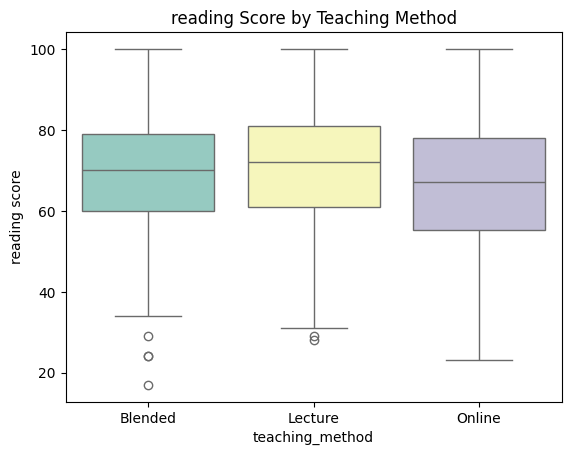


Group means:
teaching_method
Blended    69.410658
Lecture    71.073239
Online     66.858896
Name: reading score, dtype: float64


/tmp/ipykernel_2747/2822672465.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('teaching_method')['reading score'].mean())


In [14]:
sns.boxplot(x='teaching_method', y='reading score', data=data, palette='Set3')
plt.title('reading Score by Teaching Method')
plt.show()
print('\nGroup means:')
print(data.groupby('teaching_method')['reading score'].mean())

In [15]:

print('Shapiro-Wilk normality test by group:')
for m in data['teaching_method'].cat.categories:
    vals = data.loc[data['teaching_method']==m, 'reading score']
    stat,p = stats.shapiro(vals)
    print(f'{m}: W={stat:.3f}, p={p:.4f}')
stat,p = stats.levene(
    data.loc[data['teaching_method']=='Lecture','reading score'],
    data.loc[data['teaching_method']=='Online','reading score'],
    data.loc[data['teaching_method']=='Blended','reading score']
)
print('\nLevene test for equal variances: W={:.3f}, p={:.4f}'.format(stat,p))

Shapiro-Wilk normality test by group:
Blended: W=0.988, p=0.0090
Lecture: W=0.988, p=0.0057
Online: W=0.990, p=0.0319

Levene test for equal variances: W=1.260, p=0.2841


Shapiro-Wilk normality test:  In this case, it appears that the reading scores for all three teaching methods violate the assumption of normality because the p-value for each case is less than 0.05.

Levene Test:
As the p-value is greater than 0.05 so we can say the variances of reading scores across the three teaching methods are approximately equal (homogeneity of variances).

Results: It is more significant concern for the validity of the One-Way ANOVA results.

In [16]:
model1 = ols('Q(\'reading score\') ~ C(teaching_method)', data=data).fit()
anova1 = sm.stats.anova_lm(model1, typ=2)
print('One-Way ANOVA results:')
print(anova1)

One-Way ANOVA results:
                           sum_sq     df         F    PR(>F)
C(teaching_method)    3045.630261    2.0  7.232956  0.000761
Residual            209906.808739  997.0       NaN       NaN


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Blended Lecture   1.6626 0.2984 -0.9649  4.2901  False
Blended  Online  -2.5518 0.0662  -5.234  0.1305  False
Lecture  Online  -4.2143 0.0005 -6.8269 -1.6018   True
------------------------------------------------------


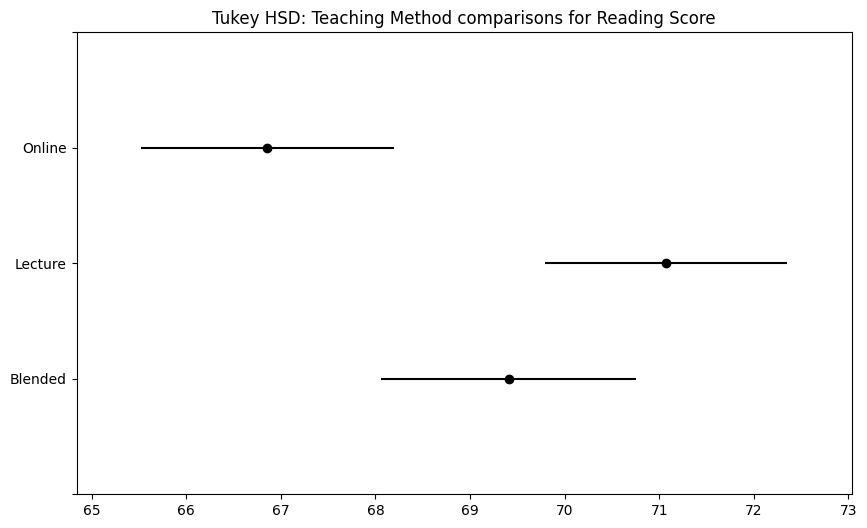

In [17]:
tukey_reading = pairwise_tukeyhsd(endog=data['reading score'], groups=data['teaching_method'], alpha=0.05)
print(tukey_reading)
tukey_reading.plot_simultaneous()
plt.title('Tukey HSD: Teaching Method comparisons for Reading Score')
plt.show()

Tukey HSD Post-Hoc Analysis for Reading Scores:

No significant difference was found in mean reading scores between the 'Blended' and 'Lecture' teaching methods, nor between the 'Blended' and 'Online' methods.


A statistically significant difference was observed between the 'Lecture' and 'Online' teaching methods (p < 0.05), with students in the 'Lecture' method achieving significantly higher mean reading scores compared to those in the 'Online' method.

/tmp/ipykernel_2747/1324973293.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='teaching_method', y='writing score', data=data, palette='Set2')


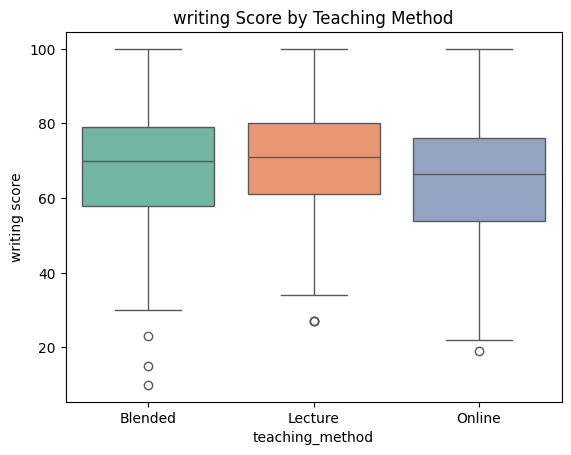


Group means:
teaching_method
Blended    68.554859
Lecture    69.853521
Online     65.604294
Name: writing score, dtype: float64


/tmp/ipykernel_2747/1324973293.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(data.groupby('teaching_method')['writing score'].mean())


In [18]:
sns.boxplot(x='teaching_method', y='writing score', data=data, palette='Set2')
plt.title('writing Score by Teaching Method')
plt.show()
print('\nGroup means:')
print(data.groupby('teaching_method')['writing score'].mean())

In [19]:
print('Shapiro-Wilk normality test by group:')
for m in data['teaching_method'].cat.categories:
    vals = data.loc[data['teaching_method']==m, 'writing score']
    stat,p = stats.shapiro(vals)
    print(f'{m}: W={stat:.3f}, p={p:.4f}')
stat,p = stats.levene(
    data.loc[data['teaching_method']=='Lecture','writing score'],
    data.loc[data['teaching_method']=='Online','writing score'],
    data.loc[data['teaching_method']=='Blended','writing score']
)
print('\nLevene test for equal variances: W={:.3f}, p={:.4f}'.format(stat,p))

Shapiro-Wilk normality test by group:
Blended: W=0.985, p=0.0017
Lecture: W=0.989, p=0.0086
Online: W=0.993, p=0.1613

Levene test for equal variances: W=0.743, p=0.4761


Normality: The Shapiro-Wilk test indicates that writing scores for the 'Blended' and 'Lecture' teaching methods significantly deviate from a normal distribution (p < 0.05). However, the 'Online' method's writing scores appear to be normally distributed (p > 0.05).

Homogeneity of Variances: The Levene's test (p > 0.05) suggests that the variances of writing scores are approximately equal across all three teaching methods, satisfying the assumption of homogeneity of variances.

In [20]:
model1 = ols('Q(\'writing score\') ~ C(teaching_method)', data=data).fit()
anova1 = sm.stats.anova_lm(model1, typ=2)
print('One-Way ANOVA results:')
print(anova1)

One-Way ANOVA results:
                           sum_sq     df         F    PR(>F)
C(teaching_method)    3185.956945    2.0  6.981369  0.000975
Residual            227491.127055  997.0       NaN       NaN


Result: Since the p-value is less than 0.05, we can conclude that the teaching method has a statistically significant effect on students' writing scores.

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Blended Lecture   1.2987 0.5054 -1.4367   4.034  False
Blended  Online  -2.9506 0.0354 -5.7429 -0.1583   True
Lecture  Online  -4.2492 0.0008  -6.969 -1.5294   True
------------------------------------------------------


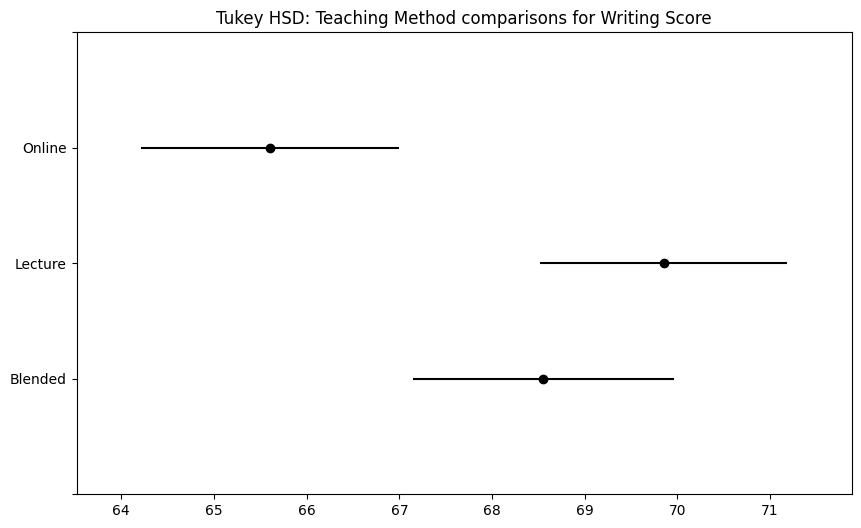

In [21]:
tukey_writing = pairwise_tukeyhsd(endog=data['writing score'], groups=data['teaching_method'], alpha=0.05)
print(tukey_writing)
tukey_writing.plot_simultaneous()
plt.title('Tukey HSD: Teaching Method comparisons for Writing Score')
plt.show()

Tukey HSD Post-Hoc Analysis for Writing Scores:

No statistically significant difference was found in mean writing scores between the 'Blended' and 'Lecture' teaching methods.

A significant statistical difference was observed between the 'Online' method and both the 'Blended' and 'Lecture' methods.

In summary, both the 'Lecture' and 'Blended' teaching methods resulted in significantly higher writing scores compared to the 'Online' teaching method.



In [22]:
# Calculate Partial Eta-Squared for Reading Score
ss_effect_reading = 3045.630261
ss_error_reading = 209906.808739
partial_eta_squared_reading = ss_effect_reading / (ss_effect_reading + ss_error_reading)
print(f"Partial Eta-Squared for Reading Score: {partial_eta_squared_reading:.3f}")

# Calculate Partial Eta-Squared for Writing Score
ss_effect_writing = 3185.956945
ss_error_writing = 227491.127055
partial_eta_squared_writing = ss_effect_writing / (ss_effect_writing + ss_error_writing)
print(f"Partial Eta-Squared for Writing Score: {partial_eta_squared_writing:.3f}")

# Calculate Partial Eta-Squared for Math Score
ss_effect_math = 1751.198763
ss_error_math = 220984.709205
partial_eta_squared_math = ss_effect_math / (ss_effect_math + ss_error_math)
print(f"Partial Eta-Squared for Math Score: {partial_eta_squared_math:.3f}")

Partial Eta-Squared for Reading Score: 0.014
Partial Eta-Squared for Writing Score: 0.014
Partial Eta-Squared for Math Score: 0.008


Result: The teaching method accounts for approximately 1.4% of the variance in both reading and writing scores, and about 0.8% of the variance in math scores.

##Detailed Policy Recommendation based on ANOVA Results:

Key findings indicate a statistically significant effect of teaching method on both reading and writing scores (with effect sizes, partial eta-squared, of approximately 1.4% for each). However, no significant impact was observed on math scores.

Crucially, post-hoc Tukey HSD tests revealed that for both reading and writing, there was no significant difference in mean scores between the 'Blended' and 'Lecture' methods. The 'Online' method, however, generally resulted in lower scores compared to 'Lecture' for both subjects, and also compared to 'Blended' for writing.

##Recommendations:

Strategic Integration of Online Learning: Given the small effect sizes (teaching method explaining less than 1.5% of variance) and the inherent flexibility and accessibility of online classes, a blanket exclusion of online methods is not advisable. Instead, efforts should focus on identifying specific  strengths within the 'Lecture' and 'Blended' approaches that contribute to slightly higher reading and writing outcomes. These effective strategies should then be carefully integrated and optimized within online learning environments to enhance their efficacy.



##Assessment of Student Success Factors:

Since teaching method explains only a minor portion of score variance, it is imperative to investigate other significant factors influencing student performance. This includes, but is not limited to, student engagement levels, individual learning styles, prior academic preparation, and broader socio-economic contexts. Future research and policy development should encompass a more comprehensive understanding of these multivariate influences.



#Qualitative Insights Engagement:

To gain a deeper understanding of why 'Lecture' and 'Blended' methods may slightly outperform 'Online' in certain areas, we recommend conducting qualitative research. This could involve surveys, focus groups, or interviews with students and educators to gather nuanced perspectives on their experiences, preferences, and perceived effectiveness of different instructional techniques.
